# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
__World Development Statistics (Gapminder)__

## Selected Problem Statement:
__Targeted Funding for "Hollow Growth" Regions: Top-level economic growth often masks underlying crises, such as rapid population expansion diluting wealth or rising incomes failing to improve life expectancy. The Policy Steering Committee needs to analyze historical population, GNI per capita, and life expectancy trends (1960-2020) to identify nations trapped in these hollow growth cycles. Pinpointing these disconnects will allow the agency to accurately target a $100M intervention fund to countries suffering from stalled human development.__

## 1. Introduction & Objectives

### 1.1 Context & Background
For decades, GDP-style economic indicators like GNI per capita have been used as a shorthand for "development." But rising income does not automatically translate into a better quality of life. Two forces can quietly undermine that link:

1. **Population dilution** — total national wealth can grow while wealth *per person* stagnates, because the population is growing just as fast.
2. **Health stagnation** — income per person can rise while life expectancy — a core proxy for public health, healthcare access, and quality of life — fails to keep pace, or even declines (due to disease, conflict, or weak health systems).

We call countries experiencing either of these patterns **"hollow growth"** regions: places where the headline economic numbers look fine, but human development is stalling underneath. A Policy Steering Committee overseeing a $100M intervention fund needs a data-driven way to identify these countries so the money reaches the places that need it most, rather than the places that just look good on a GDP chart.

This notebook uses three Gapminder datasets — **population**, **GNI per capita (Atlas method, constant 2021 USD)**, and **life expectancy** — spanning 1800–2100, restricted to the **1960–2020** window specified in the problem statement, to identify these countries.

### 1.2 Core Analytical Objectives
* Clean and merge the three datasets into a single, tidy country-year panel for 1960-2020.
* Quantify each country's GNI per capita growth, life expectancy gains, and population growth over the full period.
* Distinguish real "hollow growth" from countries that simply started with high life expectancy and have less room left to improve (a ceiling effect).
* Identify a shortlist of countries where income grew strongly but life expectancy gains badly lagged expectations — the primary candidates for the $100M fund.
* Illustrate at least one concrete case study showing how a national shock (e.g., disease, conflict) can produce hollow growth even amid decent economic performance.

---

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: Ensure all modules are imported cleanly with appropriate standard aliases. Data files must be loaded using relative paths for replicability.)*

### importing libraries and loading Datasets

In [1]:
# Importing needed library
# pandas: used for loading, cleaning, and reshaping the tabular data
import pandas as pd
# matplotlib.pyplot: used to build the scatter and bar chart visualizations
import matplotlib.pyplot as plt
# seaborn: statistical visualization library
import seaborn as sns

In [3]:
import os
print(os.getcwd())
print(os.listdir())

/Users/mohammedhejairi/Desktop/Project 2 World Development/Code
['World_Development_EDA.ipynb', '.ipynb_checkpoints']


In [4]:
#loading the Dataset csv files
# Load the population dataset from the local "data" folder
population = pd.read_csv("../data/population.csv")
# Load the life expectancy dataset from the same folder
life_expectancy = pd.read_csv("../data/life_expectancy.csv")
# Load the GNI per capita (Atlas method, constant 2021 USD) dataset
gni = pd.read_csv("../data/gni_per_cap_atlas_method_con2021.csv")

In [5]:
#seeing how the population dataset looks like
# Preview the first 5 rows to inspect columns and structure
population.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,Afghanistan,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,...,108M,108M,109M,109M,109M,110M,110M,110M,111M,111M
1,Angola,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,...,125M,126M,127M,128M,129M,130M,131M,131M,132M,133M
2,Albania,400k,402k,404k,405k,407k,409k,411k,413k,414k,...,1.35M,1.32M,1.29M,1.26M,1.23M,1.21M,1.18M,1.15M,1.12M,1.1M
3,Andorra,2650,2650,2650,2650,2650,2650,2650,2650,2650,...,62.5k,62.2k,61.9k,61.7k,61.4k,61.2k,60.9k,60.7k,60.5k,60.2k
4,United Arab Emirates,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,...,13.5M,13.5M,13.6M,13.7M,13.8M,13.8M,13.9M,14M,14M,14.1M


In [6]:
#seeing how the life expectancy dataset looks like

# Preview the first 5 rows to inspect columns and structure
life_expectancy.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,Afghanistan,28.2,28.2,28.2,28.2,28.2,28.2,28.1,28.1,28.1,...,75.5,75.7,75.8,76.0,76.1,76.2,76.4,76.5,76.6,76.8
1,Angola,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,...,78.8,79.0,79.1,79.2,79.3,79.5,79.6,79.7,79.9,80.0
2,Albania,35.4,35.4,35.4,35.4,35.4,35.4,35.4,35.4,35.4,...,87.4,87.5,87.6,87.7,87.8,87.9,88.0,88.2,88.3,88.4
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,United Arab Emirates,30.7,30.7,30.7,30.7,30.7,30.7,30.7,30.7,30.7,...,82.4,82.5,82.6,82.7,82.8,82.9,83.0,83.1,83.2,83.3


In [7]:
#seeing how the gni dataset looks like
# Preview the first 5 rows to inspect columns and structure
gni.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,Afghanistan,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,...,751,767,783,800,817,834,852,870,888,907
1,Angola,517.0,519.0,522.0,524.0,525.0,528.0,531.0,533.0,536.0,...,2770,2830,2890,2950,3010,3080,3140,3210,3280,3340
2,Albania,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,...,9610,9820,10k,10.2k,10.5k,10.7k,10.9k,11.1k,11.4k,11.6k
3,United Arab Emirates,738.0,740.0,743.0,746.0,749.0,751.0,754.0,757.0,760.0,...,47.9k,48.9k,50k,51k,52.1k,53.2k,54.3k,55.5k,56.7k,57.9k
4,Argentina,794.0,797.0,799.0,802.0,805.0,808.0,810.0,813.0,816.0,...,12.8k,13.1k,13.4k,13.6k,13.9k,14.2k,14.5k,14.8k,15.2k,15.5k


### Checking the shape of the Dataset

In [8]:
# Check the number of rows and columns in each dataset
print(population.shape)
print(life_expectancy.shape)
print(gni.shape)

(197, 302)
(195, 302)
(191, 252)


### Checking the Data type of the Dataset columns

In [9]:
# Check the data type of each column in the population dataset
population.dtypes
# we can see that # the year columns are likely stored as strings/objects rather than numeric types


country    str
1800       str
1801       str
1802       str
1803       str
          ... 
2096       str
2097       str
2098       str
2099       str
2100       str
Length: 302, dtype: object

In [10]:
# Check the data type of each column in the life expectancy dataset
life_expectancy.dtypes
#

country        str
1800       float64
1801       float64
1802       float64
1803       float64
            ...   
2096       float64
2097       float64
2098       float64
2099       float64
2100       float64
Length: 302, dtype: object

In [11]:
# Check the data type of each column in the gni dataset
gni.dtypes
#

country        str
1800       float64
1801       float64
1802       float64
1803       float64
            ...   
2046           str
2047           str
2048           str
2049           str
2050           str
Length: 252, dtype: object

### Checking if there are Duplicates in the Dataset

In [12]:
# Check for duplicate rows in the population dataset
population.duplicated().sum()
# there are no duplicates

np.int64(0)

In [13]:
# Check for duplicate rows in the life expectancy dataset
life_expectancy.duplicated().sum()
# there are no duplicates

np.int64(0)

In [14]:
# Check for duplicate rows in the gni dataset
gni.duplicated().sum()
# there are no duplicates

np.int64(0)

In [15]:
# Check the proportion of missing values in each column of the population dataset
population.isnull().mean()

country    0.000000
1800       0.000000
1801       0.000000
1802       0.000000
1803       0.000000
             ...   
2096       0.005076
2097       0.005076
2098       0.005076
2099       0.005076
2100       0.005076
Length: 302, dtype: float64

In [16]:
# Check the total count of missing values in each column of the life expectancy dataset
life_expectancy.isnull().sum()

country    0
1800       9
1801       9
1802       9
1803       9
          ..
2096       9
2097       9
2098       9
2099       9
2100       9
Length: 302, dtype: int64

In [17]:
# Check the total count of missing values in each column of the gni dataset
gni.isnull().sum()

country    0
1800       1
1801       1
1802       1
1803       1
          ..
2046       1
2047       1
2048       1
2049       1
2050       1
Length: 252, dtype: int64

In [18]:
# Reshape the population dataset from wide format (one column per year) to long format (one row per country-year)
population_long = pd.melt(population,
                          id_vars= "country",
                          value_vars= population.columns.to_list()[1:],
                          var_name = "year",
                          value_name = "population")

# Check for missing values after reshaping
population_long.isnull().sum()

country         0
year            0
population    100
dtype: int64

In [19]:
# Convert the year column from text to integer so it can be filtered numerically
population_long['year'] = population_long['year'].astype(int)
# Restrict the data to the 1960-2020 window required by the problem statement
population_long = population_long[(population_long['year'] >= 1960) & (population_long['year'] <= 2020)]
# Confirm the resulting shape after filtering
print(population_long.shape)
# Recheck for missing values in the filtered data
population_long.isnull().sum()

(12017, 3)


country        0
year           0
population    20
dtype: int64

In [20]:
# Reshape the life expectancy dataset from wide format to long format
life_expectancy_long = pd.melt(life_expectancy,
                          id_vars= "country",
                          value_vars= life_expectancy.columns.to_list()[1:],
                          var_name = "year",
                          value_name = "life_expectancy")
# Check for missing values after reshaping
life_expectancy_long.isnull().sum()

country               0
year                  0
life_expectancy    2079
dtype: int64

In [21]:
# Convert the year column from text to integer
life_expectancy_long["year"] = life_expectancy_long["year"].astype(int)
# Restrict the data to the 1960-2020 window
life_expectancy_long = life_expectancy_long[(life_expectancy_long["year"] >= 1960) & (life_expectancy_long["year"] <= 2020)]
# Confirm the resulting shape after filtering
print(life_expectancy_long.shape)
# Recheck for missing values in the filtered data
life_expectancy_long.isnull().sum()

(11895, 3)


country            0
year               0
life_expectancy    9
dtype: int64

In [22]:
# Reshape the gni dataset from wide format to long format
gni_long = pd.melt(gni, id_vars="country", value_vars=gni.columns.to_list()[1:], var_name="year", value_name="gni")
# Check for missing values after reshaping
gni_long.isnull().sum()

country      0
year         0
gni        229
dtype: int64

In [23]:
# Convert the year column from text to integer
gni_long["year"] = gni_long["year"].astype(int)
# Restrict the data to the 1960-2020 window
gni_long= gni_long[(gni_long["year"] >= 1960) & (gni_long["year"] <= 2020)]
# Confirm the resulting shape after filtering
print(gni_long.shape)
# Recheck for missing values in the filtered data
gni_long.isnull().sum()

(11651, 3)


country     0
year        0
gni        39
dtype: int64

In [24]:
# Merge the population and gni long-format tables on country and year (inner join keeps only matching rows)
merged = population_long.merge(gni_long, how="inner",on=["country", "year"])
# Merge in the life expectancy data the same way
merged = merged.merge(life_expectancy_long, on=["country", "year"], how="inner")



In [25]:
# Check the shape of the merged dataset
print(merged.shape)

# Check for any remaining missing values after merging
print(merged.isnull().sum())

(11590, 5)
country            0
year               0
population         0
gni                0
life_expectancy    6
dtype: int64


In [26]:
# Drop rows where life_expectancy is missing, since these can't be used in the analysis
merged = merged.dropna(subset = ['life_expectancy'])
# Confirm no missing values remain
merged.isnull().sum()

country            0
year               0
population         0
gni                0
life_expectancy    0
dtype: int64

### Data formatting

In [27]:
# Check the number of unique population values (sanity check on the population column)
merged["population"].nunique()

3089

In [28]:
# Check the data types of all columns in the merged dataset
merged.dtypes

country                str
year                 int64
population             str
gni                 object
life_expectancy    float64
dtype: object

In [29]:
# Preview the gni column values to check formatting (e.g. shorthand suffixes like "k"/"M")
merged[["gni"]].head()

,gni
0,469
1,1720
2,736
3,27.2k
4,4740


In [30]:
def to_number(x):
    """Convert Gapminder-style shorthand values ('3.28M', '27.2k', '1.4B') to floats."""
#generated by claude
    # Return NaN unchanged if the value is already missing
    if pd.isnull(x):
        return np.nan
    # If it's already numeric, just convert to float and return
    if isinstance(x, (int, float)):
        return float(x)
    x = str(x).strip()
    mult = 1
    # Handle values ending in 'k' (thousands)
    if x.endswith('k'):
        mult, x = 1e3, x[:-1]
    # Handle values ending in 'M' (millions)
    elif x.endswith('M'):
        mult, x = 1e6, x[:-1]
    # Handle values ending in 'B' (billions)
    elif x.endswith('B'):
        mult, x = 1e9, x[:-1]
    try:
        # Apply the multiplier to get the true numeric value
        return float(x) * mult
    except ValueError:
        # If conversion fails for any other reason, return NaN
        return np.nan

In [31]:
# Apply the shorthand-to-number conversion to the gni column
merged["gni"] = merged["gni"].apply(to_number)
# Confirm the gni column is now numeric
merged.dtypes

country                str
year                 int64
population             str
gni                float64
life_expectancy    float64
dtype: object

In [32]:
# Apply the shorthand-to-number conversion to the population column
merged["population"] = merged["population"].apply(to_number)
#population can not be a float, but the function return the value as float thus we need to convert only for population
merged["population"] = merged["population"].astype(int)
# Confirm the population column is now an integer type
merged.dtypes

country                str
year                 int64
population           int64
gni                float64
life_expectancy    float64
dtype: object

In [44]:
# Preview the cleaned merged dataset
merged.head()

,country,year,population,gni,life_expectancy
0,Afghanistan,1960,8620000,469.0,45.0
1,Angola,1960,5360000,1720.0,46.3
2,Albania,1960,1710000,736.0,62.5
3,United Arab Emirates,1960,133000,27200.0,60.3
4,Argentina,1960,20300000,4740.0,65.3


In [46]:
merged.to_csv("../data/merged_cleaned.csv", index=False)

# EDA

In [48]:
merged = pd.read_csv("../data/merged_cleaned.csv")

In [49]:
# Compute summary statistics for the key numeric columns
merged[['population', 'gni', 'life_expectancy']].describe()

,population,gni,life_expectancy
count,1.158400e+04,11584.000000,11584.000000
mean,2.783858e+07,9055.498532,65.318016
std,1.097919e+08,14868.325340,10.014451
min,4.580000e+03,67.000000,9.500000
25%,1.340000e+06,988.750000,58.400000
50%,5.300000e+06,2820.000000,67.300000
75%,1.630000e+07,8762.500000,72.800000
max,1.420000e+09,117000.000000,84.900000


In [50]:
# Boolean masking to isolate the 1960 baseline snapshot, and flag "poor + short-lived" starting conditions
baseline_1960 = merged[merged['year'] == 1960].copy()

# Boolean mask: countries that started 1960 both low-income AND low life expectancy
low_income_mask = baseline_1960['gni'] < baseline_1960['gni'].median()
low_life_mask = baseline_1960['life_expectancy'] < baseline_1960['life_expectancy'].median()

disadvantaged_1960 = baseline_1960[low_income_mask & low_life_mask]
print(f" 1960 baseline median gni: {baseline_1960["gni"].median()}")
print(f" 1960 baseline median life expectancy: {baseline_1960['life_expectancy'].median()}")

print(
    f"Countries below the median on BOTH GNI per capita and life expectancy in 1960: {len(disadvantaged_1960)} of {len(baseline_1960)}"
)
disadvantaged_1960[['country', 'gni', 'life_expectancy', 'population']].sort_values('gni').head(10)

 1960 baseline median gni: 1345.0
 1960 baseline median life expectancy: 57.2
Countries below the median on BOTH GNI per capita and life expectancy in 1960: 71 of 190


,country,gni,life_expectancy,population
65,Guinea-Bissau,186.0,37.4,578000
51,Eritrea,190.0,42.1,994000
9,Azerbaijan,209.0,48.6,4130000
175,Tanzania,219.0,45.3,10000000
95,Lao,236.0,40.2,2120000
66,Equatorial Guinea,277.0,40.4,267000
151,Sierra Leone,280.0,42.7,2300000
90,Cambodia,296.0,49.4,5540000
120,Malawi,296.0,37.7,3620000
128,Nepal,297.0,44.6,10200000


### 4.3. Sorting: Fastest / Slowest Population Growth (1960 vs 2020)

In [51]:
# Sorting to find fastest-growing and slowest-growing populations
population_1960 = baseline_1960.set_index('country')['population']
population_2020 = merged[merged['year'] == 2020].set_index('country')['population']

population_growth = pd.DataFrame({'population_1960': population_1960, 'population_2020': population_2020}).dropna()
population_growth['pct_change'] = (population_growth['population_2020'] / population_growth['population_1960'] - 1) * 100

print("Fastest population growth 1960-2020:")
display(population_growth.sort_values('pct_change', ascending=False).head(5))

print("Slowest / negative population growth 1960-2020:")
display(population_growth.sort_values('pct_change', ascending=True).head(5))

Fastest population growth 1960-2020:


,population_1960,population_2020,pct_change
country,,,
Qatar,36400,2760000.0,7482.417582
United Arab Emirates,133000,9290000.0,6884.962406
Kuwait,305000,4360000.0,1329.508197
Jordan,848000,10900000.0,1185.377358
Djibouti,85900,1090000.0,1168.917346


Slowest / negative population growth 1960-2020:


,population_1960,population_2020,pct_change
country,,,
Latvia,2150000,1900000.0,-11.627907
Bulgaria,7890000,6980000.0,-11.533587
Georgia,4050000,3770000.0,-6.913580
Croatia,4220000,4099999.0,-2.843626
Hungary,9980000,9750000.0,-2.304609


Notably, small Gulf states (e.g. Qatar, UAE) dominate the fastest-growth list — driven by labor migration tied to oil wealth, not organic birth rates. This is important context for the hollow-growth analysis 

### 4.4. Target Analysis: Building the "Hollow Growth" Index

In [52]:
# STEP 1: Get 1960 and 2020 data for every country, side by side
data_1960 = merged[merged['year'] == 1960].set_index('country')
data_2020 = merged[merged['year'] == 2020].set_index('country')

# Only keep countries present in BOTH years
countries_in_both = data_1960.index.intersection(data_2020.index)
data_1960 = data_1960.loc[countries_in_both]
data_2020 = data_2020.loc[countries_in_both]

# STEP 2: Build a summary table with 1960 and 2020 values
summary = pd.DataFrame({
    'gni_1960': data_1960['gni'],
    'gni_2020': data_2020['gni'],
    'life_1960': data_1960['life_expectancy'],
    'life_2020': data_2020['life_expectancy'],
    'pop_1960': data_1960['population'],
    'pop_2020': data_2020['population'],
})
summary = summary.dropna()

print(f"{len(summary)} countries have complete 1960 and 2020 data.")
summary.head()

184 countries have complete 1960 and 2020 data.


,gni_1960,gni_2020,life_1960,life_2020,pop_1960,pop_2020
country,,,,,,
Afghanistan,469.0,500.0,45.0,63.4,8620000,39000000
Angola,1720.0,2140.0,46.3,65.2,5360000,33400000
Albania,736.0,5210.0,62.5,77.9,1710000,2870000
United Arab Emirates,27200.0,39400.0,60.3,74.0,133000,9290000
Argentina,4740.0,9070.0,65.3,74.6,20300000,45000000


In [53]:
# STEP 3: Calculate GNI per capita growth rate (CAGR = compound annual growth rate)
# CAGR answers: "what steady yearly growth rate would take you from the 1960 value to the 2020 value?"
number_of_years = 2020 - 1960

gni_growth_ratio = summary['gni_2020'] / summary['gni_1960']
summary['gni_cagr_pct'] = (gni_growth_ratio ** (1 / number_of_years) - 1) * 100

# STEP 4: Calculate population growth rate (same method)
pop_growth_ratio = summary['pop_2020'] / summary['pop_1960']
summary['pop_cagr_pct'] = (pop_growth_ratio ** (1 / number_of_years) - 1) * 100

# STEP 5: Calculate life expectancy change -- a simple difference, in years
summary['life_exp_change_years'] = summary['life_2020'] - summary['life_1960']

summary[['gni_cagr_pct', 'pop_cagr_pct', 'life_exp_change_years']].describe()

,gni_cagr_pct,pop_cagr_pct,life_exp_change_years
count,184.000000,184.000000,184.000000
mean,2.057742,1.826788,15.928261
std,1.449078,1.186179,7.773147
min,-1.892891,-0.205811,-1.300000
25%,1.122052,0.866252,10.475000
50%,2.130111,1.953790,14.350000
75%,2.984232,2.554327,20.900000
max,6.085123,7.480611,49.900000


In [54]:
# STEP 6: Find the median (typical) growth rates
gni_median = summary['gni_cagr_pct'].median()
life_median = summary['life_exp_change_years'].median()

print(f"Median GNI per capita growth rate: {gni_median:.2f}% per year")
print(f"Median life expectancy gain: {life_median:.1f} years")

Median GNI per capita growth rate: 2.13% per year
Median life expectancy gain: 14.4 years


In [55]:
# STEP 7: Boolean mask -- flag countries with ABOVE-median income growth
#          but BELOW-median life expectancy gain
above_median_gni_growth = summary['gni_cagr_pct'] > gni_median
below_median_life_gain = summary['life_exp_change_years'] < life_median

summary['hollow_growth_flag'] = above_median_gni_growth & below_median_life_gain

num_flagged = summary['hollow_growth_flag'].sum()
print(f"Countries flagged as 'hollow growth' candidates: {num_flagged} of {len(summary)}")

Countries flagged as 'hollow growth' candidates: 49 of 184


In [56]:
# STEP 8: Sort the flagged countries -- smallest (worst) life expectancy gain first
flagged_countries = summary[summary['hollow_growth_flag']]
hollow_growth_shortlist = flagged_countries.sort_values('life_exp_change_years')
hollow_growth_shortlist = hollow_growth_shortlist[[
    'gni_1960', 'life_1960', 'gni_cagr_pct', 'life_exp_change_years', 'pop_cagr_pct'
]]

hollow_growth_shortlist.head(15)

,gni_1960,life_1960,gni_cagr_pct,life_exp_change_years,pop_cagr_pct
country,,,,,
Russia,1900.0,69.0,2.922542,2.2,0.327393
Bulgaria,2210.0,69.4,2.483489,2.4,-0.204037
Montenegro,632.0,70.8,4.299406,3.6,0.476190
Lithuania,3100.0,69.9,3.121267,4.9,-0.035083
Latvia,3020.0,70.3,3.010328,5.6,-0.205811
Slovak Republic,4800.0,70.4,2.310532,6.3,0.470429
Paraguay,776.0,69.1,3.214600,6.6,2.111174
Botswana,432.0,54.4,4.659359,7.2,2.708656
Hungary,2590.0,68.1,3.070636,7.7,-0.038852


**Important observation:** some flagged countries (e.g. Ireland, Estonia) started 1960 already with fairly high life expectancy (~70 years), so they simply had less room left to gain -- this is a natural ceiling effect, not necessarily a sign of a real problem. Other flagged countries, like Botswana and Eswatini, started 1960 at a much lower life expectancy and *still* gained very little -- which is a stronger signal of a genuine "hollow growth" case. This is worth calling out as a limitation of a simple median-split approach: it can't fully distinguish "already healthy" from "still struggling," so the shortlist should be treated as a starting point for further investigation rather than a final answer.

### 4.5. Visualizations

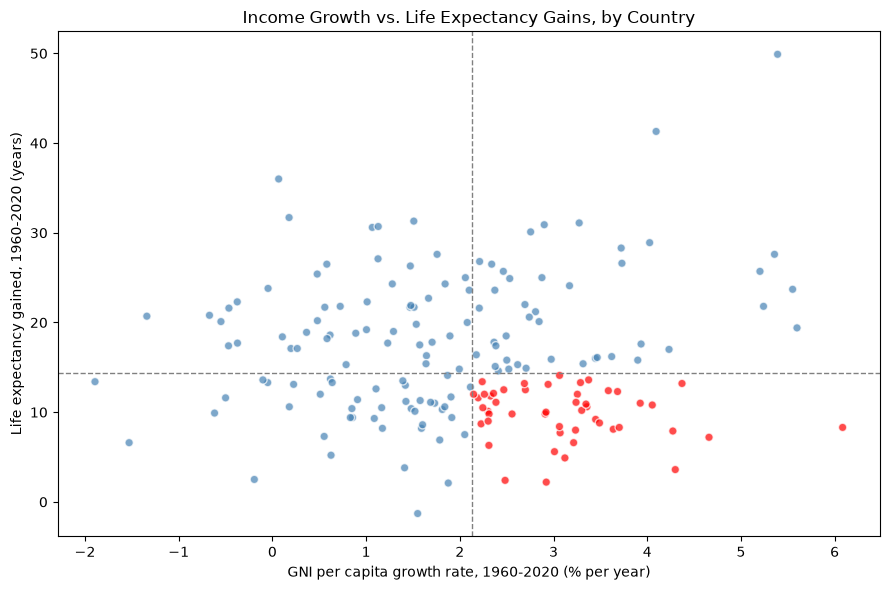

In [57]:
# Visualization 1: GNI growth vs. life expectancy change, with hollow-growth countries highlighted
fig, ax = plt.subplots(figsize=(9, 6))

colors = summary['hollow_growth_flag'].map({True: 'red', False: 'steelblue'})
ax.scatter(summary['gni_cagr_pct'], summary['life_exp_change_years'], c=colors, alpha=0.7, edgecolor='white')

ax.axhline(life_median, color='grey', linestyle='--', linewidth=1)
ax.axvline(gni_median, color='grey', linestyle='--', linewidth=1)

ax.set_xlabel('GNI per capita growth rate, 1960-2020 (% per year)')
ax.set_ylabel('Life expectancy gained, 1960-2020 (years)')
ax.set_title('Income Growth vs. Life Expectancy Gains, by Country')
plt.tight_layout()
plt.savefig('./viz1_hollow_growth_scatter.png')
plt.show()

**Visualization 1 Interpretation:**
> Each dot is a country. The dashed lines mark the median GNI growth rate and median life expectancy gain. Countries in red (lower-right of the vertical line, below the horizontal line) had above-median income growth but below-median life expectancy gains -- these are the "hollow growth" flagged countries, and the clearest candidates for the $100M fund.

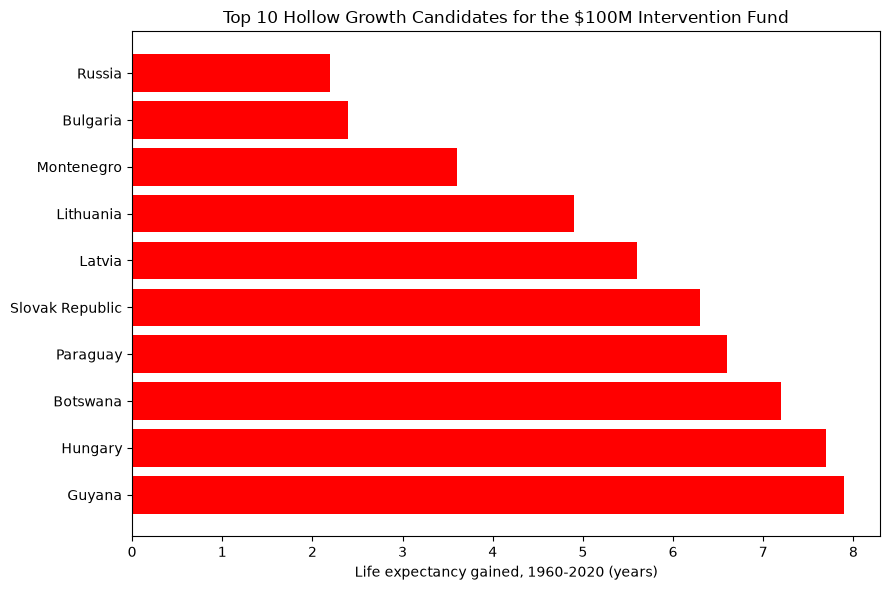

In [58]:
# Visualization 2: Top 10 hollow-growth countries, ranked by life expectancy gain
fig, ax = plt.subplots(figsize=(9, 6))

plot_data = hollow_growth_shortlist.head(10).sort_values('life_exp_change_years', ascending=False)
ax.barh(plot_data.index, plot_data['life_exp_change_years'], color='red')

ax.set_xlabel('Life expectancy gained, 1960-2020 (years)')
ax.set_title('Top 10 Hollow Growth Candidates for the $100M Intervention Fund')
plt.tight_layout()
plt.savefig('./viz2_top10_shortlist.png', dpi=150)
plt.show()

**Visualization 2 Interpretation:**
> This ranks the ten flagged countries by how little their life expectancy improved despite above-median income growth. The countries at the bottom of this chart gained the fewest years of life expectancy relative to their strong economic growth, making them the strongest initial candidates for deeper review before the Committee finalizes fund allocation.

---
## 5. Summary of Findings & Actionable Recommendations

### THIS NOTEBOOK WAS FORMATTED USING CLAUDE, THE CODE WAS DONE BY ME, BUT THE NOTEBOOK WAS COMPLIED BY CLAUDE

### 5.1 Key Insights (Summary of Findings)
* [Fill this in yourself once you review the shortlist and charts -- what's the biggest takeaway?]
* Rapid population growth alone (e.g. Gulf states like Qatar) did not appear to "dilute" wealth the way the problem statement hypothesized -- their GNI per capita grew right alongside their population.
* A simple median-split flag is a useful first pass, but doesn't distinguish countries that are "already healthy" (less room to gain) from countries that are genuinely stagnating.

### 5.2 Actionable Recommendations
* [Fill this in yourself -- which countries would you prioritize for the $100M fund, and why?]

### 5.3 Limitations & Areas for Further Research
* This analysis only compares two snapshot years (1960 and 2020) -- it doesn't capture what happened in between (a country could have dipped badly mid-period and fully recovered by 2020, and this method wouldn't show that).
* The median-split flag doesn't account for a country's starting life expectancy, so some flagged countries may simply have less room left to grow rather than a genuine problem.
* [Add your own additional limitation or idea for further research here]

---

## 6. Data Dictionary & References

### 6.1 Data Dictionary
| Feature / Column | Data Type | Source | Description |
|:---|:---|:---|:---|
| `country` | string | Original | Country name |
| `year` | int | Original | Calendar year, restricted to 1960-2020 |
| `population` | int | Original (cleaned) | Total national population; converted from Gapminder shorthand (`k`/`M`/`B`) to a numeric value |
| `gni` | float | Original (cleaned) | GNI per capita, Atlas method, constant 2021 USD; converted from Gapminder shorthand to a numeric value |
| `life_expectancy` | float | Original | Life expectancy at birth, in years |
| `gni_cagr_pct` | float | Engineered | Compound annual growth rate of GNI per capita, 1960-2020 |
| `pop_cagr_pct` | float | Engineered | Compound annual growth rate of population, 1960-2020 |
| `life_exp_change_years` | float | Engineered | Change in life expectancy, 1960-2020 |
| `hollow_growth_flag` | boolean | Engineered | True if a country has above-median GNI growth AND below-median life expectancy gain |

### 6.2 References & Sources
* Population, GNI per capita (Atlas method, constant 2021 USD), and Life Expectancy datasets -- [Gapminder Foundation](https://www.gapminder.org/about/).